# Exploratory Data Analysis

In [1]:
#Importing essential libraries
from openpyxl import load_workbook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx

#Libraries for machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

#Setting seed for reproducibility
np.random.seed(55)

In [2]:
df = pd.read_csv("clean_pcos_data.csv")

### Correlation Matrix 

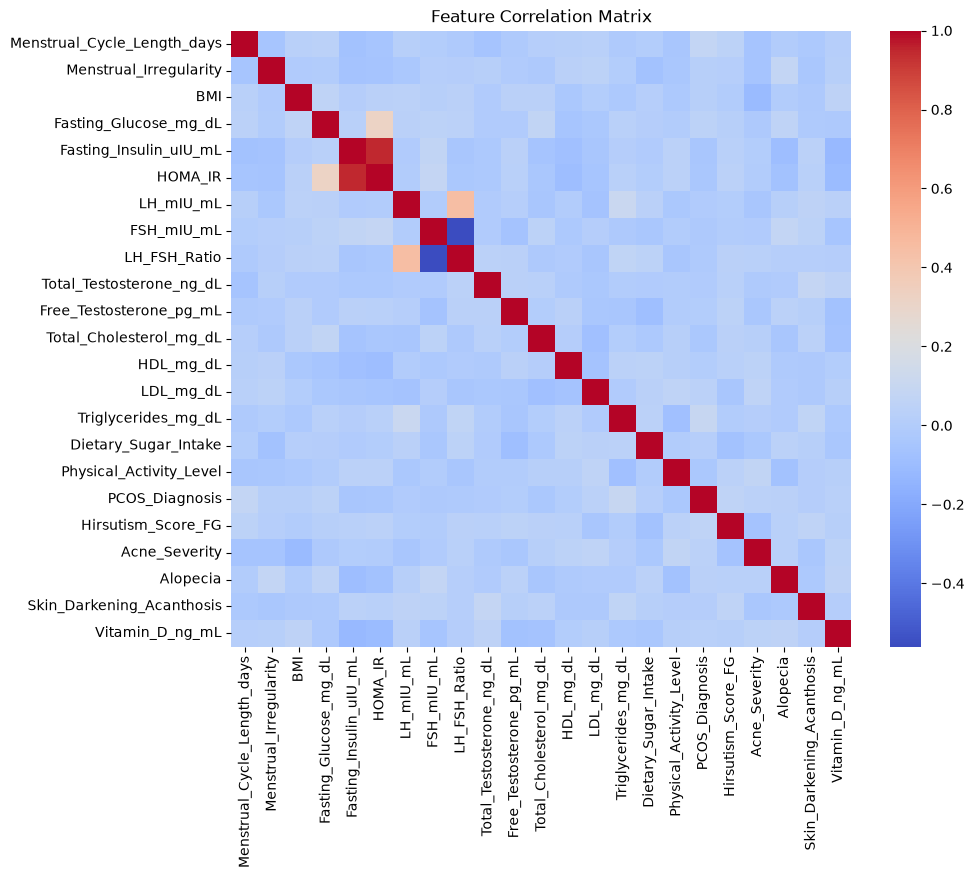

In [3]:
#Correlation matrix visualisation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

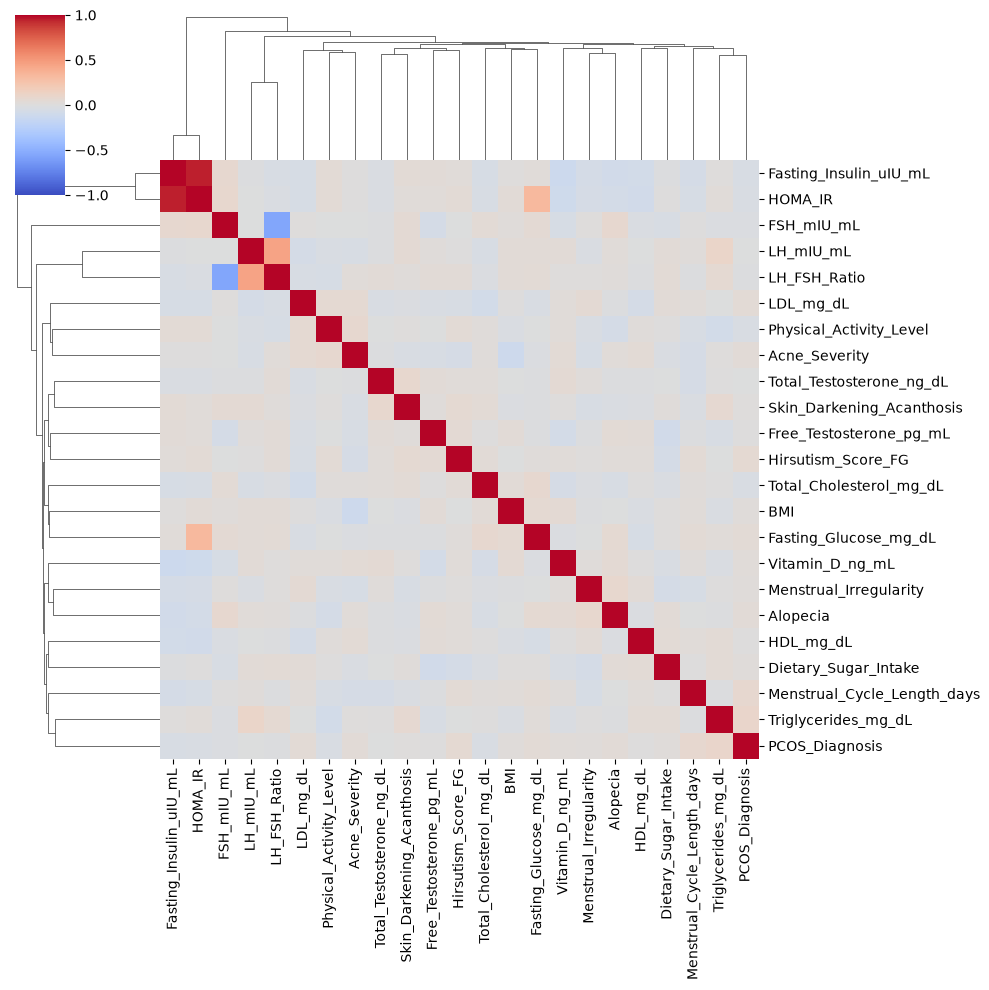

In [4]:
#Clustered heatmap
sns.clustermap(df.corr(), cmap='coolwarm', vmin=-1, vmax=1, annot=False)

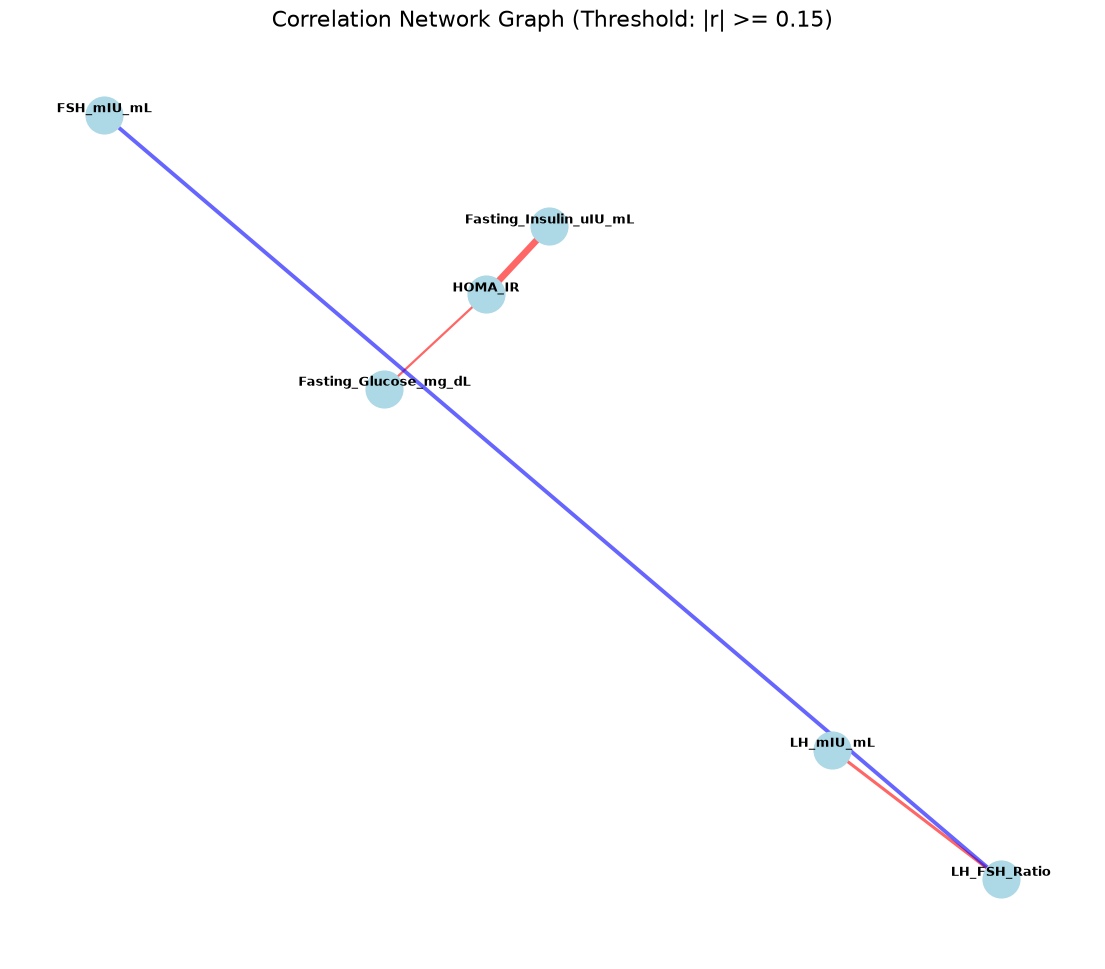

In [5]:
#Thresholded Correlation Network Graph

#Creating the correlation map and creating an empty graph
corr = df.corr()
graph = nx.Graph()

#Setting a threshold
threshold = 0.15

#Adding edges based on if they are equal to or above the threshold 0.4
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) >= threshold:
            #Saving the edge with the correlation value
            graph.add_edge(corr.columns[i], corr.columns[j], weight=val)

#Removing isolated nodes with no strong correlations
isolated_nodes = [node for node, degree in dict(graph.degree()).items() if degree == 0]
graph.remove_nodes_from(isolated_nodes)

#Setting up layout 
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(graph, k=0.4, seed = 55)
edges= graph.edges(data=True) #retrieving weights for size and colour of edges
weights = [edge[2]['weight'] for edge in edges]
edge_colors = ['red' if w > 0 else 'blue' for w in weights]
edge_widths = [abs(w) * 5 for w in weights]

#Drawing components
nx.draw_networkx_nodes(graph, pos, node_color='lightblue', node_size = 700)
nx.draw_networkx_edges(graph, pos, edgelist=edges, edge_color = edge_colors, width=edge_widths, alpha = 0.6)
nx.draw_networkx_labels(graph, pos, font_size=9, font_weight='bold', verticalalignment = 'bottom')

plt.title(f"Correlation Network Graph (Threshold: |r| >= 0.15)", fontsize=16)
plt.axis('off')
plt.show()


#K-Means Clustering to Cluster PCOS Phenotypes for enhanced, hybrid recommender system


In [6]:
#Filtering the dataset to only apply K-means clustering to PCOS patients
pcos_only_df = df[df['PCOS_Diagnosis'] == 1].copy()

phenotype_features = [
    'HOMA_IR', 'BMI', 'Triglycerides_mg_dL',
    'Total_Testosterone_ng_dL', 'Menstrual_Cycle_Length_days',
    'Hirsutism_Score_FG', 'LH_FSH_Ratio'
]

#Applying the phenotypes to the dataset only for clustering
X_clustering = pcos_only_df[phenotype_features].copy()

#Fitting and transforming using a standard scaler 
scaler_cluster = StandardScaler()
X_clustering_scaled = scaler_cluster.fit_transform(X_clustering)

#Executing K-Means clustering
kmeans_model = KMeans(n_clusters=4, random_state = 82, n_init = 10)
pcos_only_df['Clinical_Cluster'] = kmeans_model.fit_predict(X_clustering_scaled)

#Printing the clustering results - clinical clusters
print(f"K-Means Clustering was executed on {len(pcos_only_df)} verified PCOS patients.")
print(pcos_only_df['Clinical_Cluster'].value_counts().rename(lambda x: f"PCOS Phenotype Cluster {x}"))

K-Means Clustering was executed on 208 verified PCOS patients.
Clinical_Cluster
PCOS Phenotype Cluster 1    69
PCOS Phenotype Cluster 3    66
PCOS Phenotype Cluster 0    61
PCOS Phenotype Cluster 2    12
Name: count, dtype: int64


### Evaluating the K-Means Clusters

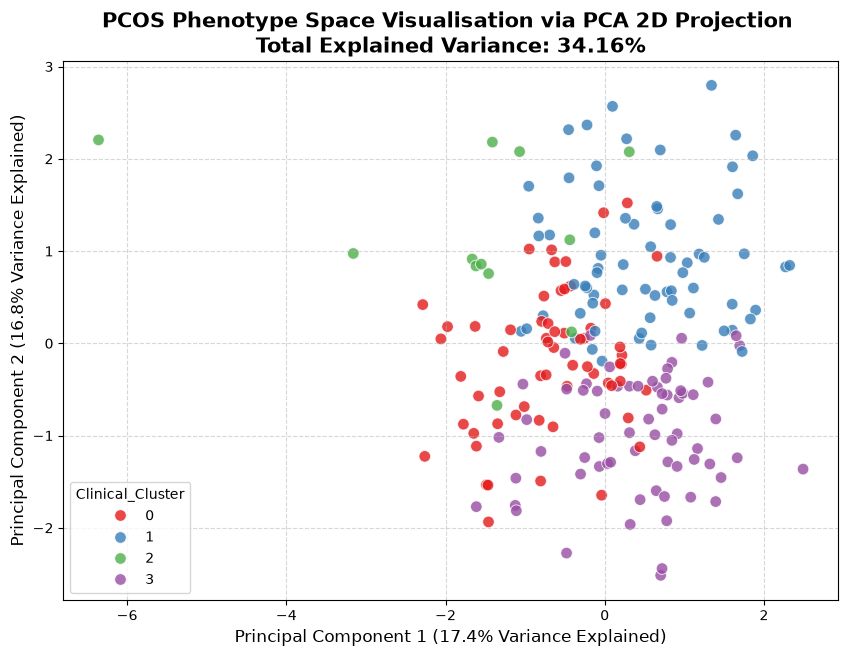

In [7]:
#The K-Means Clustering is in a 7-Dimensional Coordinate Space due to 7 phenotype features
#Therefore to visualise the K-Means clusters, PCA is used to project the data to a 2D plane
#This is to assess the maximum possible geometric variance between patients

#Initialising PCA to reduce 7D scaled features down to 2 Principal Components
pca = PCA(n_components=2, random_state=50)
X_pca = pca.fit_transform(X_clustering_scaled)
#Attaching these coordinates back to the filtered dataframe
pcos_only_df['PCA_1'] = X_pca[:, 0]
pcos_only_df['PCA_2'] = X_pca[:, 1]

#Plotting the clusters onto a 2D Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA_1', y='PCA_2',
    hue='Clinical_Cluster',
    palette='Set1',
    data=pcos_only_df,
    alpha=0.8,
    edgecolor='w', s=70
)

#Calculating the variance explained by the axes
exp_var = pca.explained_variance_ratio_ * 100

plt.title(f'PCOS Phenotype Space Visualisation via PCA 2D Projection \nTotal Explained Variance: {exp_var[0]+exp_var[1]:.2f}%', fontsize=15, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({exp_var[0]:.1f}% Variance Explained)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({exp_var[1]:.1f}% Variance Explained)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Raw Phenotypic Characteristics Matrix (Cluster Means):
-------------------------------------------------------------------------------------
                  HOMA_IR    BMI  Triglycerides_mg_dL  \
Clinical_Cluster                                        
0                    3.78  24.88               170.18   
1                    3.99  27.22               164.67   
2                    3.27  29.03               128.83   
3                    2.03  22.59               120.39   

                  Total_Testosterone_ng_dL  Menstrual_Cycle_Length_days  \
Clinical_Cluster                                                          
0                                    61.44                        26.89   
1                                    47.75                        35.97   
2                                    51.08                        29.42   
3                                    56.52                        35.05   

                  Hirsutism_Score_FG  LH_FSH_Ratio  
Clinical_Clu

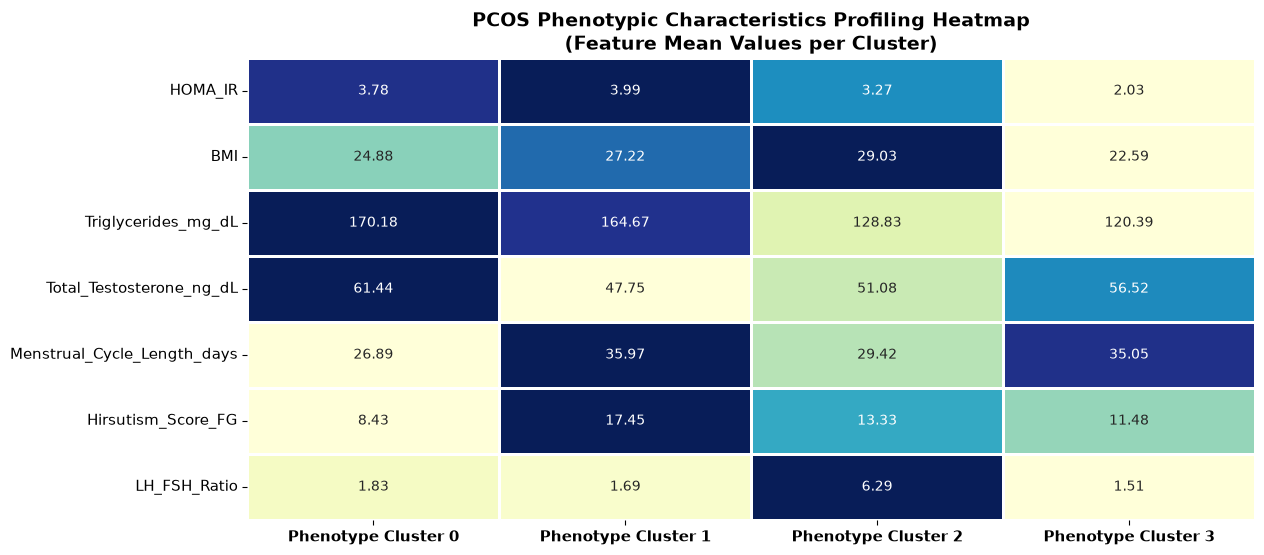

In [8]:
#Discovering characteristics of the phenotypes from K-means clustering
#To compare the clinical results of the K-means clusters to Clinical Standard Rotterdam phenotypes
#The mean feature values for each cluster is calculated 
cluster_profiles = pcos_only_df.groupby('Clinical_Cluster')[phenotype_features].mean()
print("Raw Phenotypic Characteristics Matrix (Cluster Means):")
print("-" * 85)
print(cluster_profiles.round(2))
print("-" * 85)

#Visualising the cluster phenotype characteristics as a normalised heatmap for clarity
#Scaling the columns locally so I can see which cluster scores 'highest' or 'lowest' for each trait
phenotype_scaler = MinMaxScaler()
cluster_phenotype_scaled = pd.DataFrame(
    phenotype_scaler.fit_transform(cluster_profiles),
    columns=cluster_profiles.columns,
    index=[f"Phenotype Cluster {i}" for i in cluster_profiles.index]
)

#Plotting the heatmap
plt.figure(figsize=(13, 6))
sns.heatmap(cluster_phenotype_scaled.T, annot=cluster_profiles.T.values, fmt=".2f", cmap="YlGnBu", cbar=False, linewidths=1)
plt.title("PCOS Phenotypic Characteristics Profiling Heatmap\n(Feature Mean Values per Cluster)", fontsize=14, fontweight='bold')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11)
plt.show()

In [9]:
#Mathematical evaluation of the quality of the K-means Clusters using 3 metrics
sil_score = silhouette_score(X_clustering_scaled, pcos_only_df['Clinical_Cluster'])
db_score = davies_bouldin_score(X_clustering_scaled, pcos_only_df['Clinical_Cluster'])
ch_score = calinski_harabasz_score(X_clustering_scaled, pcos_only_df['Clinical_Cluster'])

print(f"Silhouette Coefficient: {sil_score:3f} (Target is to be close to +1.0)")
print(f"Davies-Bouldin Index: {db_score:.3f} (Target is to get a lower score to indicate cleaner cluster seperations)")
print(f"Calinski-Harabasz Index: {ch_score:.1f} (Target is a higher score to indicate tighter clusters)")

Silhouette Coefficient: 0.108026 (Target is to be close to +1.0)
Davies-Bouldin Index: 1.989 (Target is to get a lower score to indicate cleaner cluster seperations)
Calinski-Harabasz Index: 23.8 (Target is a higher score to indicate tighter clusters)


### Computing true centroid (mean profile) for each of the 4 Rotterdam clusters to generate expert PCOS profiles for more personalised recommendations for PCOS patients

In [10]:
#Calculating the true centroid (mean profile) for each of the 4 Rotterdam Clusters
cluster_centroids = pcos_only_df.groupby('Clinical_Cluster')[phenotype_features].mean()

#Initialising a dictionary to store the 5D master target vecgtor for each cluster
